# Q1. Consider the medal tally across all years. Which are the top-5 provinces-- in terms of highest podium finishes? (6.5 M)


In [ ]:
# First we must import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.read_csv("canada_games.csv")

,year,sport,event,province,finish_position
0,2009,Athletics,Athletics Event 1,Nova Scotia,4
1,2009,Athletics,Athletics Event 2,New Brunswick,5
2,2009,Athletics,Athletics Event 3,Manitoba,7
3,2009,Athletics,Athletics Event 4,Prince Edward Island,3
4,2009,Athletics,Athletics Event 5,Nova Scotia,3
...,...,...,...,...,...
795,2022,Gymnastics,Gymnastics Event 36,New Brunswick,3
796,2022,Gymnastics,Gymnastics Event 37,Quebec,3
797,2022,Gymnastics,Gymnastics Event 38,Manitoba,3
798,2022,Gymnastics,Gymnastics Event 39,New Brunswick,2


In [ ]:
pd.read_csv("canada_provinces.geojson")

,"{""type"": ""FeatureCollection""","""features"": [{""type"":""Feature""","geometry:{""type"":""MultiPolygon""",coordinates:[[[[-131.077103,52.150089],[-130.948105,52.093609],[-130.992493,52.060822],[-131.070007,...,"nom:""Territoire du Yukon""",icon:null.12,"altitudemode:""relativeToGround"".12",description:null.12,"name:""Yukon""",_end:null.12,begin:null.12,timestamp:null.12,"show:""n"".4",_2012_membership:747}}]}


In [ ]:
df_games = pd.read_csv('canada_games.csv')
df_games.head()

,year,sport,event,province,finish_position
0,2009,Athletics,Athletics Event 1,Nova Scotia,4
1,2009,Athletics,Athletics Event 2,New Brunswick,5
2,2009,Athletics,Athletics Event 3,Manitoba,7
3,2009,Athletics,Athletics Event 4,Prince Edward Island,3
4,2009,Athletics,Athletics Event 5,Nova Scotia,3


In [ ]:
df_podium = df_games[df_games['finish_position'].isin([1, 2, 3])]
top_5_provinces = df_podium['province'].value_counts().nlargest(5)
print(top_5_provinces)

province
New Brunswick                45
Nova Scotia                  33
British Columbia             31
Newfoundland and Labrador    30
Manitoba                     30
Name: count, dtype: int64


# The Top 5 Provinces in terms of highest podium finishes are the following:

1. New Brunswick: 45
2. Nova Scotia: 33
3. British Columbia: 31
4. Newfoundland and Labrador: 30
5. Manitoba: 30

# Q2. Show on a map, the leading province for Bronze medals in 2022. (6.5 M)


In [ ]:
df_2022_games = df_games[df_games['year'] == 2022]
df_2022_games.head()

,year,sport,event,province,finish_position
600,2022,Athletics,Athletics Event 1,Prince Edward Island,6
601,2022,Athletics,Athletics Event 2,Prince Edward Island,5
602,2022,Athletics,Athletics Event 3,New Brunswick,6
603,2022,Athletics,Athletics Event 4,Quebec,1
604,2022,Athletics,Athletics Event 5,Ontario,7


In [ ]:
df_2022_bronze = df_2022_games[df_2022_games['finish_position'] == 3] # 3 Corresponds to third place/bronze
df_2022_bronze.head()

,year,sport,event,province,finish_position
612,2022,Athletics,Athletics Event 13,Saskatchewan,3
614,2022,Athletics,Athletics Event 15,Saskatchewan,3
628,2022,Athletics,Athletics Event 29,Newfoundland and Labrador,3
630,2022,Athletics,Athletics Event 31,Prince Edward Island,3
633,2022,Athletics,Athletics Event 34,Quebec,3


In [ ]:
find_leading_province = df_2022_bronze['province'].value_counts().idxmax()
print(find_leading_province)

Saskatchewan


In [ ]:
import geopandas as gpd

provinces_gdf = gpd.read_file('canada_provinces.geojson')
provinces_gdf.head()

,cartodb_id,draworder,visibility,extrude,tessellate,nom,icon,altitudemode,description,name,_end,begin,timestamp,show,_2012_membership,geometry
0,6,None,-1,-1,-1,Colombie-Britannique,None,relativeToGround,None,British Columbia,None,None,None,y,39859,"MULTIPOLYGON (((-131.0771 52.15009, -130.9481 ..."
1,5,None,-1,-1,-1,Terre-Neuve-et-Labrador,None,relativeToGround,None,Newfoundland and Labrador,None,None,None,n,974,"MULTIPOLYGON (((-55.88306 53.48638, -55.72944 ..."
2,13,None,-1,-1,-1,Territories Nord-Ouest,None,relativeToGround,None,Northwest Territories,None,None,None,n,124,"MULTIPOLYGON (((-110.3944 78.75221, -109.97841..."
3,12,None,-1,-1,-1,Nunavut,None,relativeToGround,None,Nunavut,None,None,None,n,24,"MULTIPOLYGON (((-109.97841 78.67106, -109.4053..."
4,3,None,-1,-1,-1,Saskatchewan,None,relativeToGround,None,Saskatchewan,None,None,None,y,11243,"MULTIPOLYGON (((-102.0017 59.99992, -102.0009 ..."


In [ ]:
provinces_gdf['is_leading_province'] = provinces_gdf['name'] == find_leading_province

In [ ]:
provinces_gdf.head()

,cartodb_id,draworder,visibility,extrude,tessellate,nom,icon,altitudemode,description,name,_end,begin,timestamp,show,_2012_membership,geometry,is_leading_province
0,6,None,-1,-1,-1,Colombie-Britannique,None,relativeToGround,None,British Columbia,None,None,None,y,39859,"MULTIPOLYGON (((-131.0771 52.15009, -130.9481 ...",False
1,5,None,-1,-1,-1,Terre-Neuve-et-Labrador,None,relativeToGround,None,Newfoundland and Labrador,None,None,None,n,974,"MULTIPOLYGON (((-55.88306 53.48638, -55.72944 ...",False
2,13,None,-1,-1,-1,Territories Nord-Ouest,None,relativeToGround,None,Northwest Territories,None,None,None,n,124,"MULTIPOLYGON (((-110.3944 78.75221, -109.97841...",False
3,12,None,-1,-1,-1,Nunavut,None,relativeToGround,None,Nunavut,None,None,None,n,24,"MULTIPOLYGON (((-109.97841 78.67106, -109.4053...",False
4,3,None,-1,-1,-1,Saskatchewan,None,relativeToGround,None,Saskatchewan,None,None,None,y,11243,"MULTIPOLYGON (((-102.0017 59.99992, -102.0009 ...",True


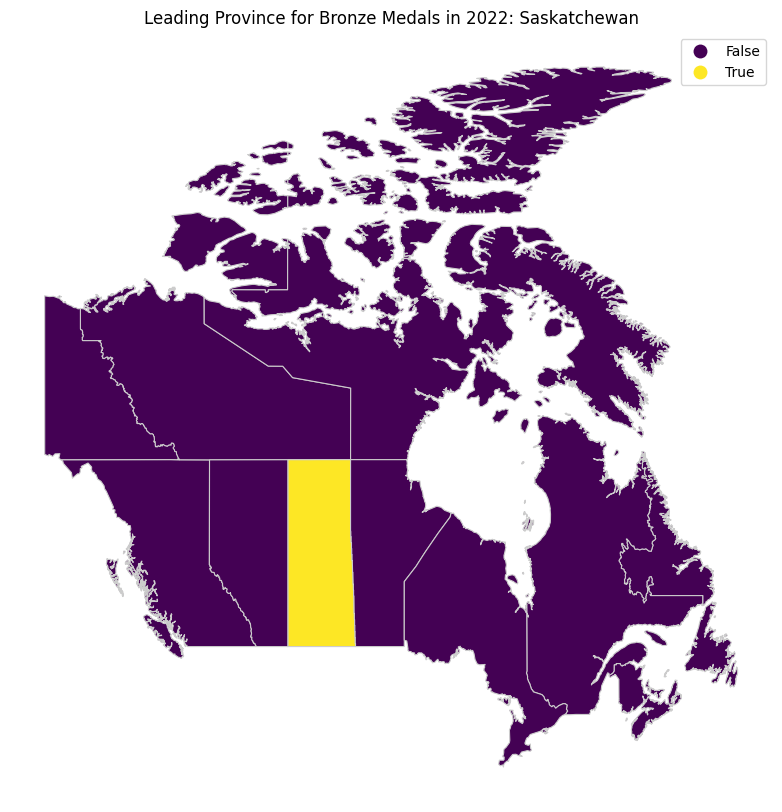

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
provinces_gdf.plot(column='is_leading_province', cmap='viridis', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
ax.set_title(f'Leading Province for Bronze Medals in 2022: {find_leading_province}')
ax.set_axis_off()
plt.show()

# The Leading Province in Bronze Medals in 2022 as shown is Saskatchewan.